<a href="https://colab.research.google.com/github/soumak4321/ATM-Simulator/blob/main/Image_Classification_Using_CNN_and_TensorFlow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import files

uploaded = files.upload()

Saving archive (4).zip to archive (4).zip


In [6]:
import zipfile

zip_ref = zipfile.ZipFile('/content/archive (4).zip', 'r')

zip_ref.extractall('/content/dataset')

zip_ref.close()

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [7]:
import os

os.listdir('/content/dataset')

['cats_set', 'dogs_set']

In [8]:
import tensorflow as tf

dataset = tf.keras.preprocessing.image_dataset_from_directory(
    '/content/dataset',
    image_size=(128,128),
    batch_size=32
)

Found 1000 files belonging to 2 classes.


In [9]:
from tensorflow.keras import layers, models

model = models.Sequential([

    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dense(2, activation='softmax')
])

In [10]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
history = model.fit(dataset, epochs=5)

Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 452ms/step - accuracy: 0.5190 - loss: 0.9890
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 456ms/step - accuracy: 0.6210 - loss: 0.6520
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 444ms/step - accuracy: 0.7130 - loss: 0.5901
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 457ms/step - accuracy: 0.7640 - loss: 0.4879
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 454ms/step - accuracy: 0.8620 - loss: 0.3357


In [12]:
loss, accuracy = model.evaluate(dataset)

print("Accuracy:", accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 148ms/step - accuracy: 0.9380 - loss: 0.2120
Accuracy: 0.9380000233650208


In [13]:
model.save("cat_dog_classifier.h5")

In [14]:
from google.colab import files

uploaded = files.upload()

Saving guvo59-british-shorthair-8032816.jpg to guvo59-british-shorthair-8032816.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
Prediction: Cat


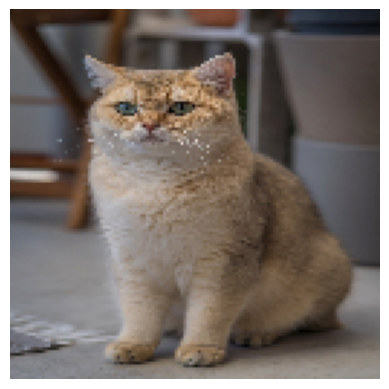

In [15]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img = image.load_img(
    'guvo59-british-shorthair-8032816.jpg',
    target_size=(128,128)
)

img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

img_array = img_array / 255.0

prediction = model.predict(img_array)

plt.imshow(img)
plt.axis('off')

if np.argmax(prediction) == 0:
    print("Prediction: Cat")
else:
    print("Prediction: Dog")

In [16]:
from google.colab import files

files.download('cat_dog_classifier.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

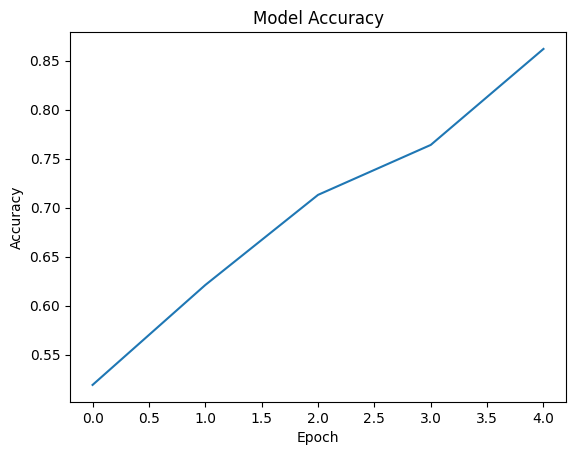

In [17]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])

plt.title('Model Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.savefig('accuracy_graph.png')

plt.show()

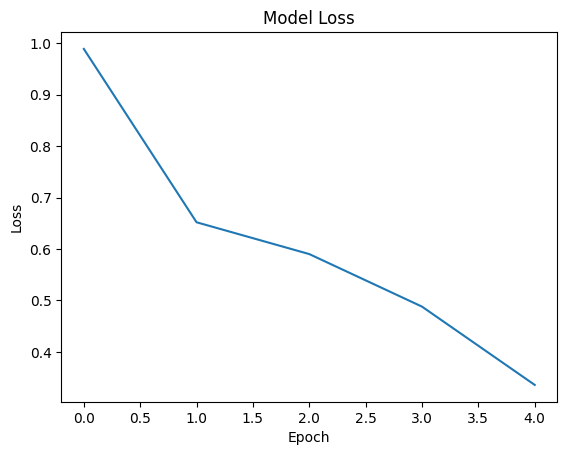

In [18]:
plt.plot(history.history['loss'])

plt.title('Model Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.savefig('loss_graph.png')

plt.show()

In [19]:
model.save("cat_dog_model.h5")

In [20]:
from google.colab import files
files.download("cat_dog_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>